In [ ]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [ ]:
# import like this
items_path = "/content/20_items.csv"
q1_path = "/content/20_quarter-1.csv"
q2_path = "/content/20_quarter-2.csv"
q3_path = "/content/20_quarter-3.csv"


q1= pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3 = pd.read_csv(q3_path)

items = pd.read_csv(items_path)

###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [ ]:
# code here
#Q-1
df = pd.concat([q1,q2,q3],ignore_index=True)

In [ ]:
df

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,1,1,$3.39
1,1,1,2,2,$3.39
2,2,2,4,3,$16.98
3,4,1,7,6,$9.25
4,6,1,9,8,$8.75
...,...,...,...,...,...
4617,1829,1,23,92,$11.25
4618,1830,1,23,1043,$11.25
4619,1832,1,10,116,$8.75
4620,1832,1,8,0,$4.45


In [ ]:
# Q-2
pd.concat([q1,q2,q3] , keys = ['Q-1','Q-2','Q-3'])

order_id quantity item_id choice_description_id item_price
Q-1 0           1        1       1                     1     $3.39 
    1           1        1       2                     2     $3.39 
    2           2        2       4                     3    $16.98 
    3           4        1       7                     6     $9.25 
    4           6        1       9                     8     $8.75 
...           ...      ...     ...                   ...        ...
Q-2 2342     1829        1      23                    92    $11.25 
    2343     1830        1      23                  1043    $11.25 
    2344     1832        1      10                   116     $8.75 
    2345     1832        1       8                     0     $4.45 
    2346     1834        1      20                   515    $11.25 

[4622 rows x 5 columns]

In [ ]:
new_df = pd.concat([q1,q2,q3] , keys = ['Q-1','Q-2','Q-3'])

In [ ]:
new_df = new_df.reset_index().drop(columns = ['level_1'])

In [ ]:
new_df = new_df.rename(columns={'level_0':'quarter'})

In [ ]:
new_df['item_price'] = new_df['item_price'].str.replace('$','',regex=False).astype('float')

In [ ]:
# Q.3

In [ ]:
ans_df = new_df.merge(items , on='item_id').groupby(['quarter','item_name'])['item_price'].sum().reset_index().sort_values(['quarter','item_price'],ascending=[True,False]).groupby('quarter').head(5)

In [ ]:
ans_df

,quarter,item_name,item_price
17,Q-1,Chicken Bowl,3525.72
18,Q-1,Chicken Burrito,2721.95
39,Q-1,Steak Burrito,1922.36
38,Q-1,Steak Bowl,1179.13
25,Q-1,Chips and Guacamole,1120.93
65,Q-2,Chicken Bowl,3817.01
66,Q-2,Chicken Burrito,2853.87
84,Q-2,Steak Burrito,1929.07
83,Q-2,Steak Bowl,1081.06
73,Q-2,Chips and Guacamole,1080.11


In [ ]:
# Q-4
#Find out items which has made most revenue in each quarter.

In [ ]:
ans_df.groupby('quarter').head(1)

,quarter,item_name,item_price
17,Q-1,Chicken Bowl,3525.72
65,Q-2,Chicken Bowl,3817.01


In [ ]:
# Q-5

In [ ]:
new_df.groupby('quarter')['item_price'].mean()

,item_price
quarter,
Q-1,7.577138
Q-2,7.354994


###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [ ]:
ipl =   pd.read_csv('/content/20_deliveries.csv')

In [ ]:
mach = pd.read_csv('/content/20_matches.csv')

In [ ]:
temp = ipl.merge(mach,left_on = 'match_id' , right_on = 'id')

In [ ]:
temp = temp[(ipl['dismissal_kind']=='caught') | (ipl['dismissal_kind']=='bowled') | (ipl['dismissal_kind']=='lbw') | (ipl['dismissal_kind']=='caught and bowled') | (ipl['dismissal_kind']=='stumped')]

In [ ]:
temp['isWicket'] = 1

In [ ]:
temp.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,isWicket
11,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,5,DA Warner,S Dhawan,A Choudhary,0,...,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1
64,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,11,3,S Dhawan,MC Henriques,STR Binny,0,...,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1
94,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,16,2,MC Henriques,Yuvraj Singh,YS Chahal,0,...,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1
116,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,19,4,Yuvraj Singh,DJ Hooda,TS Mills,0,...,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1
160,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,6,4,Mandeep Singh,CH Gayle,Rashid Khan,0,...,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1


In [ ]:
new_temp = temp.groupby(['season','bowler'])['isWicket'].sum().reset_index().sort_values(['season','isWicket'],ascending=[True,False])

In [ ]:
purple_cap_list = new_temp.groupby('season').head(1)

In [ ]:
purple_cap_list

,season,bowler,isWicket
75,2008,Sohail Tanvir,22
152,2009,RP Singh,23
241,2010,PP Ojha,21
367,2011,SL Malinga,28
437,2012,M Morkel,25
509,2013,DJ Bravo,32
639,2014,MM Sharma,23
695,2015,DJ Bravo,26
774,2016,B Kumar,23
861,2017,B Kumar,26


###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [ ]:
# code here

In [ ]:
death = ipl.merge(mach,left_on = 'match_id' , right_on = 'id')

In [ ]:
death.shape

(150460, 39)

In [ ]:
death = death[(death['over'] >= 16) & (death['over'] <= 20)]

In [ ]:
death.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied',
       'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue',
       'umpire1', 'umpire2', 'umpire3'],
      dtype='object')

In [ ]:
death.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
94,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,16,2,MC Henriques,Yuvraj Singh,YS Chahal,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN


In [ ]:
death['dismissal_kind'].unique()

array([nan, 'caught', 'bowled', 'run out', 'caught and bowled', 'lbw',
       'stumped', 'hit wicket', 'retired hurt', 'obstructing the field'],
      dtype=object)

In [ ]:
death = death[(death['dismissal_kind'] == 'caught') | (death['dismissal_kind'] == 'bowled') | (death['dismissal_kind'] == 'lbw') | (death['dismissal_kind'] == 'caught and bowled') | (death['dismissal_kind'] == 'stumped')]

In [ ]:
death.shape

(2366, 39)

In [ ]:
death['iswicket'] = 1

In [ ]:
death.groupby('bowler')['iswicket'].sum().sort_values(ascending = False).head(1).index.item()

'SL Malinga'

###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [1]:
# code here

In [22]:
ball =   pd.read_csv('/content/20_deliveries.csv')

In [24]:
import pandas as pd
import numpy as np

def batsman_season_stats(batsman_name):

    df = ball.copy()

    # 🔍 detect striker column
    striker_candidates = ['batsman', 'striker', 'batter']
    striker_col = next(
        (c for c in df.columns if c.lower() in striker_candidates),
        None
    )

    if striker_col is None:
        raise ValueError("No striker/batsman/batter column found in ball dataset")

    # 🔍 detect match id column
    match_col = next(
        (c for c in df.columns if c.lower().replace('_', '') in ['matchid', 'id']),
        None
    )

    if match_col is None:
        raise ValueError("No match id column found in ball dataset")

    # merge season info
    df = df.merge(
        match[['id', 'season']],
        left_on=match_col,
        right_on='id',
        how='left'
    )

    # striker balls only
    df = df[df[striker_col] == batsman_name]

    # legal balls only (exclude wides & no-balls)
    legal_balls = df[(df['wide_runs'] == 0) & (df['noball_runs'] == 0)]

    # aggregations
    total_runs = df.groupby('season')['batsman_runs'].sum()

    balls_faced = legal_balls.groupby('season').size()

    outs = (
        df[df['player_dismissed'] == batsman_name]
        .groupby('season')
        .size()
    )

    innings = df.groupby('season')[match_col].nunique()

    highest_score = (
        df.groupby(['season', match_col])['batsman_runs']
          .sum()
          .groupby('season')
          .max()
    )

    # final dataframe
    result = pd.DataFrame({
        'Innings': innings,
        'TotalRuns': total_runs,
        'HighestScore': highest_score,
        'BallsFaced': balls_faced,
        'Outs': outs
    }).fillna(0)

    # metrics
    result['Avg'] = result['TotalRuns'] / result['Outs'].replace(0, np.nan)
    result['StrikeRate'] = (result['TotalRuns'] / result['BallsFaced']) * 100

    result = result[['Innings', 'TotalRuns', 'Avg', 'HighestScore', 'StrikeRate']]
    result.index.name = 'Season'

    return result.round(2)


In [26]:
batsman_season_stats("V Kohli")

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
Season,,,,,
2008,12,165,15.00,38,105.10
2009,13,246,22.36,50,112.33
2010,13,307,27.91,58,145.50
2011,16,557,46.42,71,121.35
2012,15,364,30.33,73,112.00
2013,16,639,45.64,99,140.75
2014,14,359,27.62,73,122.11
2015,16,505,45.91,82,130.83
2016,16,973,81.08,113,152.75


In [27]:
batsman_season_stats("MS Dhoni")

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
Season,,,,,
2008,14,414,41.40,65,133.55
2009,13,332,41.50,58,127.20
2010,11,287,31.89,66,136.67
2011,13,392,43.56,70,160.00
2012,17,357,32.45,51,129.82
2013,16,461,46.10,67,164.64
2014,15,371,74.20,57,150.20
2015,17,372,31.00,53,121.97
2016,12,284,40.57,64,135.24


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [ ]:
# code here

In [28]:
import pandas as pd
import numpy as np


In [36]:
def player_of_match_figures(matches, ball):

    results = []

    for _, match_row in matches.iterrows():
        match_id = match_row['id']
        pom = match_row['player_of_match']

        match_balls = ball[ball['match_id'] == match_id]

        # --------------------
        # 🏏 Batting Figure
        # --------------------
        bat_df = match_balls[match_balls['batsman'] == pom]

        runs = bat_df['batsman_runs'].sum()

        balls = bat_df[
            (bat_df['wide_runs'] == 0) &
            (bat_df['noball_runs'] == 0)
        ].shape[0]

        batting_figure = f"{runs}/{balls}" if balls > 0 else np.nan

        # --------------------
        # 🎯 Bowling Figure
        # --------------------
        bowl_df = match_balls[match_balls['bowler'] == pom]

        runs_conceded = bowl_df['total_runs'].sum()

        wickets = bowl_df[
            (bowl_df['player_dismissed'].notna()) &
            (~bowl_df['dismissal_kind'].isin(['run out', 'retired hurt']))
        ].shape[0]

        bowling_figure = (
            f"{wickets}/{runs_conceded}" if bowl_df.shape[0] > 0 else np.nan
        )

        results.append({
            'PlayerOfThematch': pom,
            'BattingFigure': batting_figure,
            'BowlingFigure': bowling_figure
        })

    return pd.DataFrame(results)


In [34]:
mach = pd.read_csv('/content/20_matches.csv')

In [37]:
pom_df = player_of_match_figures(mach, ball)
pom_df.head()

,PlayerOfThematch,BattingFigure,BowlingFigure
0,Yuvraj Singh,62/27,NaN
1,SPD Smith,84/54,NaN
2,CA Lynn,93/41,NaN
3,GJ Maxwell,44/20,NaN
4,KM Jadhav,69/37,NaN


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [39]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

In [ ]:
virginica.head()

,Unnamed: 0,Id,Species
0,100,101,Iris-virginica
1,101,102,Iris-virginica
2,102,103,Iris-virginica
3,103,104,Iris-virginica
4,104,105,Iris-virginica


In [ ]:
sepal_all.head()

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm
0,0,1,5.1,3.5
1,1,2,4.9,3.0
2,2,3,4.7,3.2
3,3,4,4.6,3.1
4,4,5,5.0,3.6


In [ ]:
virginica_sepal = virginica.merge(sepal_all,how='inner')

In [ ]:
virginical_sepal_mean = virginica_sepal['SepalLengthCm'].mean().item()

In [ ]:
sesota_petal = setosa.merge(petal_all,how='inner')

In [ ]:
sesota_petal_mean = sesota_petal['PetalLengthCm'].mean().item()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
values = [virginical_sepal_mean , sesota_petal_mean]
labels = ['virginical_sepal_mean','sesota_petal_mean']

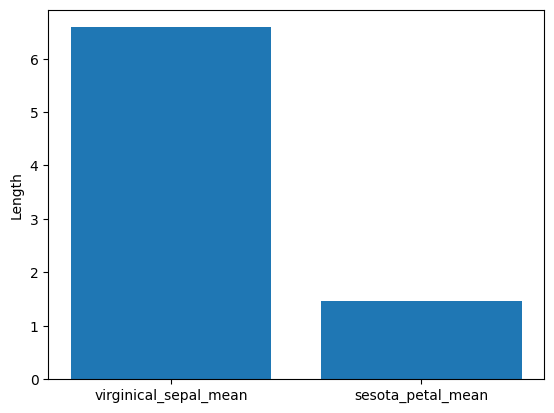

In [ ]:
plt.bar(labels, values)
plt.ylabel('Length')
plt.show()

In [ ]:
# code here

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [38]:
# code here

In [40]:
setosa['Species'] = 'setosa'
versicolor['Species'] = 'versicolor'
virginica['Species'] = 'virginica'


In [41]:
species_df = pd.concat(
    [setosa, versicolor, virginica],
    ignore_index=True
)


In [42]:
df = (
    species_df
    .merge(sepal_all, on='Id', how='inner')
    .merge(petal_all, on='Id', how='inner')
)


In [43]:
df = df[
    [
        'Id',
        'Species',
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm'
    ]
]


In [44]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [45]:
df.head()
df['Id'].is_monotonic_increasing


False

### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [47]:
# code here

In [48]:
species_df = pd.concat([setosa, versicolor], ignore_index=True)


In [49]:
merged_df = (
    species_df
    .merge(sepal_all, on='Id')
    .merge(petal_all, on='Id')
)


In [50]:
grouped = merged_df.groupby('Species')


In [51]:
stats = grouped.agg({
    'SepalWidthCm': ['min', 'max'],
    'PetalWidthCm': ['min', 'max']
})

In [53]:
for species in ['setosa', 'versicolor']:
    print(f"Minimum Sepal width of {species} is {stats.loc[species, ('SepalWidthCm', 'min')]}")
    print(f"Maximum Sepal width of {species} is {stats.loc[species, ('SepalWidthCm', 'max')]}")
    print()
    print(f"Minimum Petal width of {species} is {stats.loc[species, ('PetalWidthCm', 'min')]}")
    print(f"Maximum Petal width of {species} is {stats.loc[species, ('PetalWidthCm', 'max')]}")
    print("\n" + "*" * 50 + "\n")


Minimum Sepal width of setosa is 2.3
Maximum Sepal width of setosa is 4.4

Minimum Petal width of setosa is 0.1
Maximum Petal width of setosa is 0.6

**************************************************

Minimum Sepal width of versicolor is 2.0
Maximum Sepal width of versicolor is 3.4

Minimum Petal width of versicolor is 1.0
Maximum Petal width of versicolor is 1.8

**************************************************

